In [38]:
import sys
import re
from pathlib import Path
from typing import Dict, List, Optional, Set, Tuple

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd


In [39]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()

# Project root = .../anaconda_research_project
PROJECT_ROOT = NOTEBOOK_DIR.parents[3]

# (optional) seaborn_script root (where helpers/ lives)
SEABORN_ROOT = NOTEBOOK_DIR.parents[1]

for p in [PROJECT_ROOT, SEABORN_ROOT]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT, "outputs exists?", (PROJECT_ROOT / "outputs").exists())
print("SEABORN_ROOT:", SEABORN_ROOT, "helpers exists?", (SEABORN_ROOT / "helpers").exists())
    
from helpers.lang_profiles import get_langs
from csv_helpers import bump_field_limit
from helpers.output_writer import write_df

NOTEBOOK_DIR: D:\Work\Research_Project\anaconda_research_project\scripts\report\seaborn_script\statistics_tests
PROJECT_ROOT: D:\Work\Research_Project\anaconda_research_project outputs exists? True
SEABORN_ROOT: D:\Work\Research_Project\anaconda_research_project\scripts\report helpers exists? False


In [40]:
# ========================
# Parameters
# ========================
ALPHA = 0.05
LABELS = [0, 1, 2, 3]

LANG_PROFILE = "script"
LANGS: List[str] = get_langs(LANG_PROFILE)

METRIC = "mean_diff"

MODEL_FILTER: Optional[List[str]] = None   # e.g. ["gpt-oss-20b"]
AGGREGATE_ACROSS_MODELS = True             # recommended for “language-only” ANOVA
RUN_TUKEY_POSTHOC = True

# =========================
# Config
# =========================
TREC_DL_YEAR = "2022"
LABEL_ROOT = PROJECT_ROOT / "outputs" / "llm_label" / f"trec_dl_{TREC_DL_YEAR}"

OUT_DIR = PROJECT_ROOT / "figures" / TREC_DL_YEAR / "anova" / f"lang_only_{LANG_PROFILE}"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_SAMPLES   = OUT_DIR / "anova_samples_long.csv"
OUT_ANOVA_CSV = OUT_DIR / "anova_1way_lang_mean_diff.csv"

INVALID_CSV = NOTEBOOK_DIR / f"invalid_{TREC_DL_YEAR}.csv"
# If invalid file is in same folder as notebook, change to:
# INVALID_CSV = NOTEBOOK_ROOT / f"invalid_{TREC_DL_YEAR}.csv"

KEY_COLS = ["qid", "pid"]

print("LABEL_ROOT:", LABEL_ROOT)
print("OUT_DIR:", OUT_DIR)
print("INVALID_CSV:", INVALID_CSV)

LABEL_ROOT: D:\Work\Research_Project\anaconda_research_project\outputs\llm_label\trec_dl_2022
OUT_DIR: D:\Work\Research_Project\anaconda_research_project\figures\2022\anova\lang_only_script
INVALID_CSV: D:\Work\Research_Project\anaconda_research_project\scripts\report\seaborn_script\statistics_tests\invalid_2022.csv


In [41]:
def find_llm_files() -> Dict[str, List[Path]]:
    if not LABEL_ROOT.exists():
        raise FileNotFoundError(f"LABEL_ROOT not found: {LABEL_ROOT}")

    model_files: Dict[str, List[Path]] = {}
    for model_dir in LABEL_ROOT.iterdir():
        if not model_dir.is_dir():
            continue

        model_name = model_dir.name
        if MODEL_FILTER is not None and model_name not in set(MODEL_FILTER):
            continue

        csv_files = list(model_dir.glob(f"{model_name}_trecdl_{TREC_DL_YEAR}_*_labels.csv"))
        if csv_files:
            model_files[model_name] = csv_files

    return model_files


def get_lang_from_filename(file_path: Path, model: str) -> Optional[str]:
    fname = file_path.name
    pattern = rf"^{re.escape(model)}_trecdl_\d{{4}}_(.+?)_labels\.csv$"
    m = re.search(pattern, fname)
    return m.group(1) if m else None


def load_invalid_keys(path: Path) -> Set[Tuple[int, str]]:
    if not path.exists():
        print(f"[INFO] No invalid file found: {path}")
        return set()

    inv = pd.read_csv(path)
    if not set(KEY_COLS).issubset(inv.columns):
        raise ValueError(f"{path} must contain columns {KEY_COLS}")

    inv = inv.dropna(subset=KEY_COLS).copy()
    inv["qid"] = pd.to_numeric(inv["qid"], errors="coerce")
    inv = inv.dropna(subset=["qid"]).copy()
    inv["qid"] = inv["qid"].astype(int)
    inv["pid"] = inv["pid"].astype(str)

    keys = set(inv[KEY_COLS].drop_duplicates().itertuples(index=False, name=None))
    print(f"[INFO] Loaded {len(keys)} invalid keys from {path}")
    return keys


def load_labels(file_path: Path, invalid_keys: Set[Tuple[int, str]]) -> pd.DataFrame:
    bump_field_limit()
    df = pd.read_csv(file_path)

    req = {"qid", "pid", "relevance", "llm_relevance"}
    missing = req - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns {sorted(missing)} in {file_path}")

    df["NIST"] = pd.to_numeric(df["relevance"], errors="coerce")
    df["LLM"]  = pd.to_numeric(df["llm_relevance"], errors="coerce")

    df = df.dropna(subset=["NIST", "LLM"]).copy()
    df["NIST"] = df["NIST"].astype(int)
    df["LLM"]  = df["LLM"].astype(int)
    df = df[df["NIST"].isin(LABELS) & df["LLM"].isin(LABELS)].copy()

    df = df.dropna(subset=["qid", "pid"]).copy()
    df["qid"] = pd.to_numeric(df["qid"], errors="coerce")
    df = df.dropna(subset=["qid"]).copy()
    df["qid"] = df["qid"].astype(int)
    df["pid"] = df["pid"].astype(str)

    if invalid_keys:
        keys = pd.Index(list(zip(df["qid"].to_numpy(), df["pid"].to_numpy())))
        df = df[~keys.isin(invalid_keys)].copy()

    return df


def per_row_metric(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    base = df.drop_duplicates(subset=["qid", "pid"]).copy()

    if metric == "mean_diff":
        base["value"] = base["LLM"] - base["NIST"]
        return base[["qid", "pid", "value"]]

    if metric == "mae_4pt":
        base["value"] = (base["LLM"] - base["NIST"]).abs()
        return base[["qid", "pid", "value"]]

    if metric == "disagree_rate":
        base["value"] = (base["LLM"] != base["NIST"]).astype(float)
        return base[["qid", "pid", "value"]]

    raise ValueError("Unknown METRIC.")

In [42]:
model_files = find_llm_files()
invalid_keys = load_invalid_keys(INVALID_CSV)

rows = []
skipped = 0

print(f"Found {len(model_files)} models under: {LABEL_ROOT}")

for model, files in model_files.items():
    for f in files:
        lang = get_lang_from_filename(f, model)
        if lang is None:
            continue
        if lang not in LANGS:
            continue

        try:
            df = load_labels(f, invalid_keys)
            perrow = per_row_metric(df, METRIC)
            if perrow.empty:
                continue

            perrow["model"] = model
            perrow["lang"] = lang
            rows.append(perrow[["value", "model", "lang", "qid", "pid"]])

        except Exception as e:
            skipped += 1
            print(f"[SKIP] {model} {lang} ({f.name}): {e}")

if not rows:
    raise RuntimeError("No samples produced.")

long_df = pd.concat(rows, ignore_index=True)

# aggregate across models if desired (recommended)
if AGGREGATE_ACROSS_MODELS:
    long_df = long_df.groupby(["lang", "qid", "pid"], as_index=False)["value"].mean()

# require >=2 samples per language
counts = long_df["lang"].value_counts()
keep_langs = counts[counts >= 2].index
long_df = long_df[long_df["lang"].isin(keep_langs)].copy()

print("Languages kept:", sorted(long_df["lang"].unique()))
print("Total samples:", len(long_df))
print("Skipped files:", skipped)

# save for reproducibility
write_df(long_df, OUT_SAMPLES)
OUT_SAMPLES

[INFO] Loaded 6 invalid keys from D:\Work\Research_Project\anaconda_research_project\scripts\report\seaborn_script\statistics_tests\invalid_2022.csv
Found 3 models under: D:\Work\Research_Project\anaconda_research_project\outputs\llm_label\trec_dl_2022
Languages kept: ['ar', 'eng', 'fr', 'ja', 'ru', 'uk', 'ur', 'zh']
Total samples: 21192
Skipped files: 0


WindowsPath('D:/Work/Research_Project/anaconda_research_project/figures/2022/anova/lang_only_script/anova_samples_long.csv')

In [43]:
fit = ols("value ~ C(lang)", data=long_df).fit()
anova_tbl = anova_lm(fit, typ=2).reset_index().rename(columns={"index": "term"})
anova_tbl

,term,sum_sq,df,F,PR(>F)
0,C(lang),56.433789,7.0,11.820061,4.079598e-15
1,Residual,14448.721383,21184.0,NaN,NaN


In [44]:
write_df(anova_tbl, OUT_ANOVA_CSV)
print("Wrote:", OUT_ANOVA_CSV)

Wrote: D:\Work\Research_Project\anaconda_research_project\figures\2022\anova\lang_only_script\anova_1way_lang_mean_diff.csv


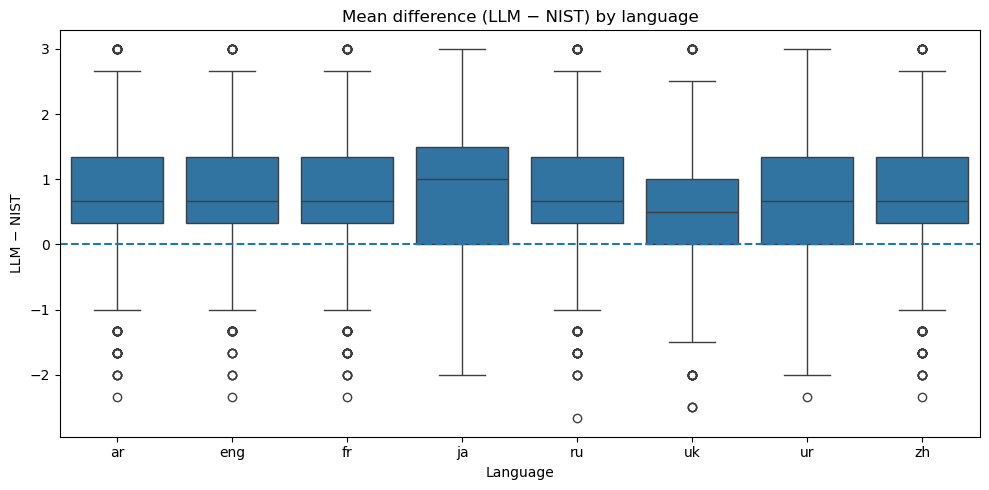

In [45]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=long_df, x="lang", y="value")
plt.axhline(0, linestyle="--")
plt.title("Mean difference (LLM − NIST) by language")
plt.xlabel("Language")
plt.ylabel("LLM − NIST")
plt.tight_layout()
plt.show()